Loaded shape: (1325, 6)
Columns: ['dlog_SOLVPN', 'dlog_COPPER', 'dlog_DXY', 'd_UST10Y', 'dlog_VIX']
Date range: 2020-10-13 00:00:00 ~ 2026-01-12 00:00:00
Usable observations after lagging: 1324
Rolling windows to estimate: 1125

========== Running tau=0.05 ==========

========== Running tau=0.5 ==========

========== Running tau=0.95 ==========


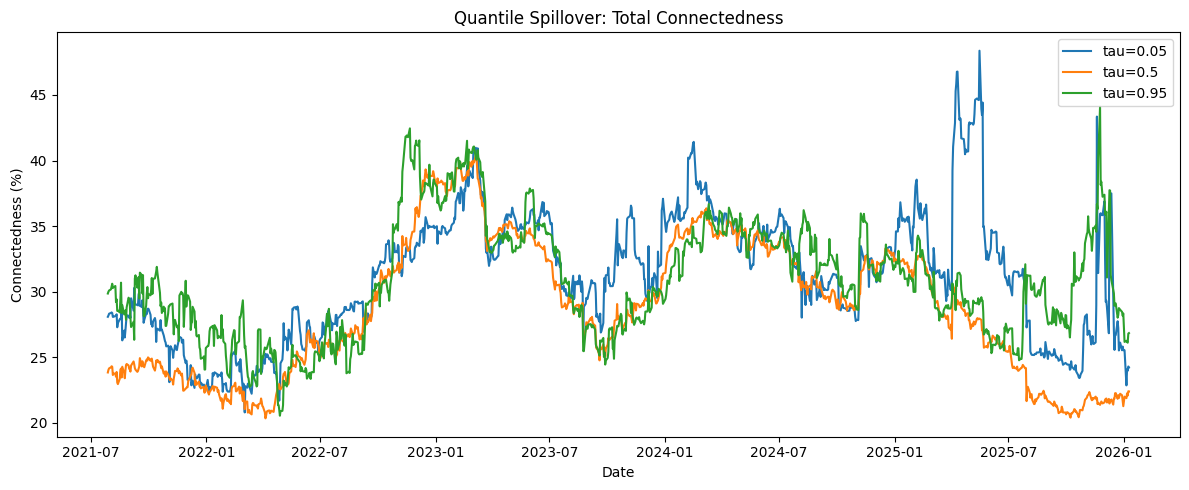

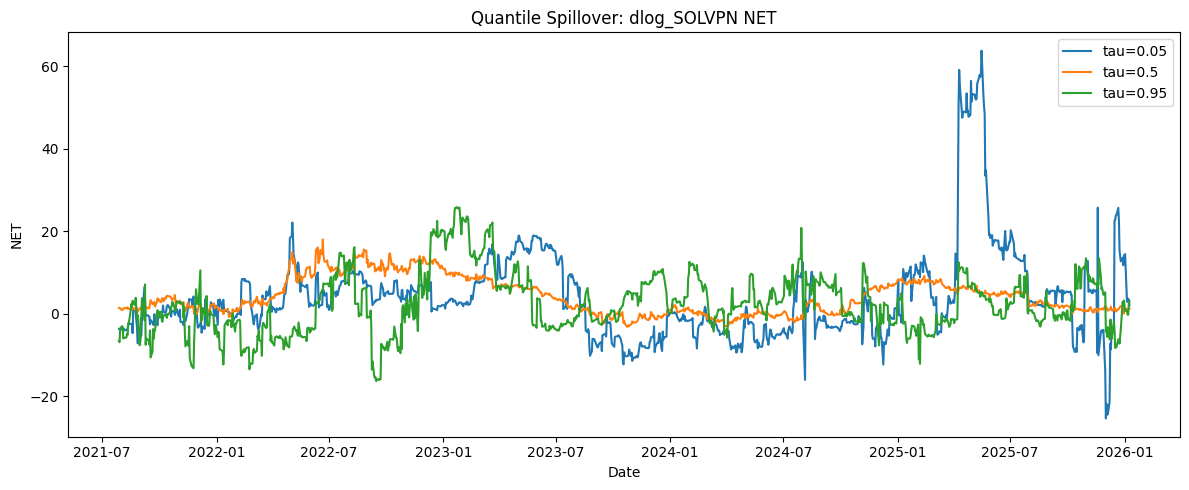

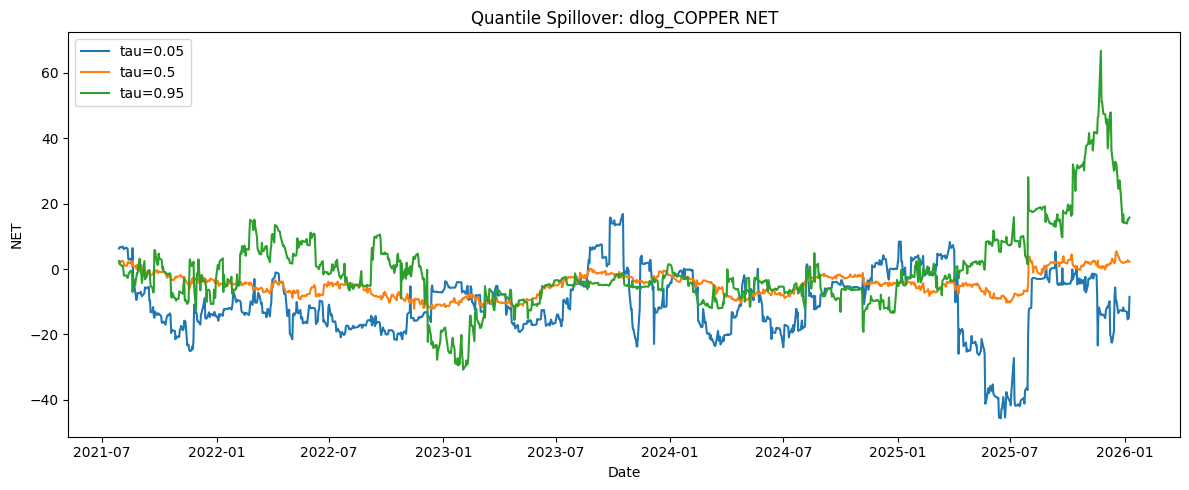

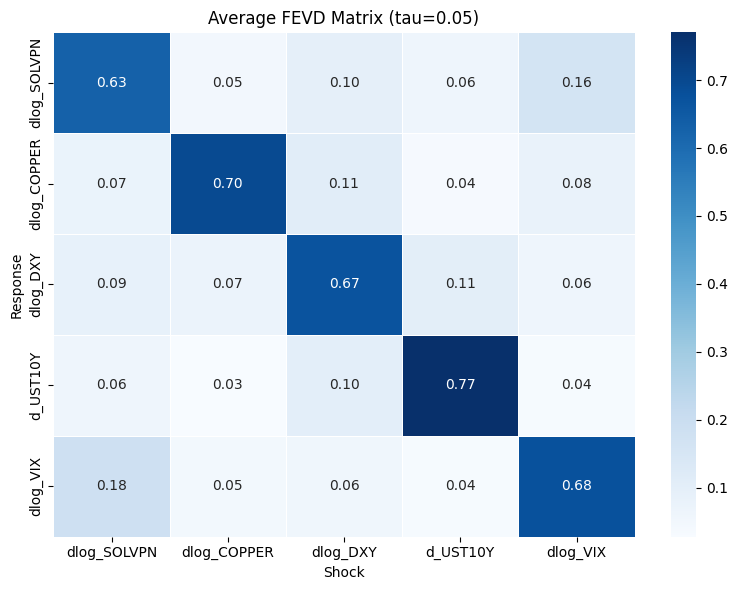

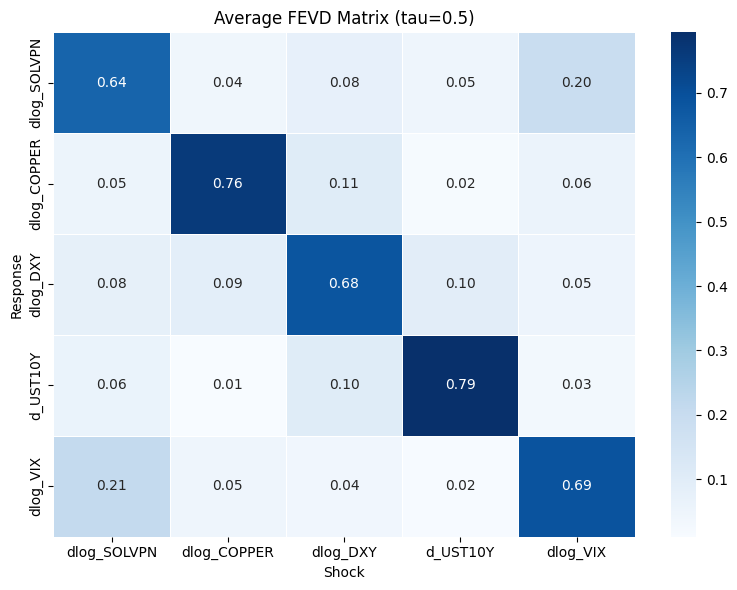

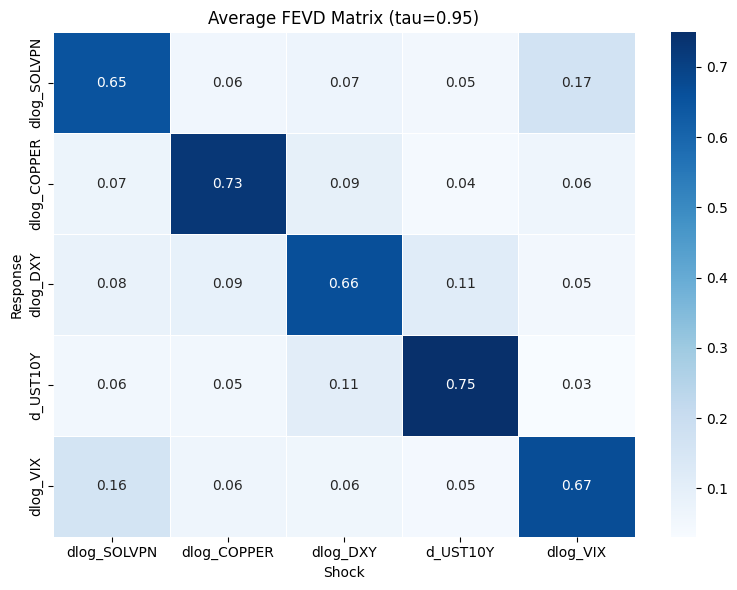


[Done] Quantile spillover completed.
Output folder: ./output_quantile_spillover

Total spillover summary by tau
    Tau  Total_Mean  Total_Std  Total_Min  Total_Max
0  0.05     31.1185     4.8494    20.7976    48.3704
1  0.50     28.7023     5.1705    20.3450    40.3882
2  0.95     30.7672     4.3260    20.5457    44.0941

Variable summary by tau (head)
     Tau     Variable  TO_Mean   TO_Std  FROM_Mean  FROM_Std  NET_Mean  \
0   0.05  dlog_SOLVPN  40.8435  13.3413    36.9180    7.8404    3.9255   
1   0.05  dlog_COPPER  19.7259   7.3413    30.4780    9.3958  -10.7521   
2   0.05     dlog_DXY  36.8955  13.9871    32.8890    8.6607    4.0065   
3   0.05     d_UST10Y  24.0326   9.7869    22.9658    9.8669    1.0668   
4   0.05     dlog_VIX  34.0948   8.1682    32.3415    5.8373    1.7533   
5   0.50  dlog_SOLVPN  40.5887   9.5944    36.4300    7.8135    4.1587   
6   0.50  dlog_COPPER  18.9122   5.1672    23.6868    5.4629   -4.7745   
7   0.50     dlog_DXY  32.4810  14.9827    31.7153 

In [2]:
# =========================================================
# Quantile Spillover for merged_var_input.csv
# - Input: ./merged_var_input.csv
# - Uses transformed/stationary columns
# - Rolling Quantile VAR(p)
# - Generalized FEVD
# - Outputs: Total / TO / FROM / NET spillover by tau
# - Heatmaps include numeric annotations
# =========================================================

import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.regression.quantile_regression import QuantReg

# =========================================================
# 0. Config
# =========================================================
DATA_PATH = "./merged_var_input.csv"
OUT_DIR = "./output_quantile_spillover"

DATE_COL = "Date"
USE_COLS = ["dlog_SOLVPN", "dlog_COPPER", "dlog_DXY", "d_UST10Y", "dlog_VIX"]

P = 1
H = 10
WINDOW = 200
TAUS = [0.05, 0.50, 0.95]

MAX_ITER = 5000
HEATMAP_FMT = ".2f"

os.makedirs(OUT_DIR, exist_ok=True)

# =========================================================
# 1. Load data
# =========================================================
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"File not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

required_cols = [DATE_COL] + USE_COLS
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)
df = df[required_cols].dropna().reset_index(drop=True)

print("Loaded shape:", df.shape)
print("Columns:", USE_COLS)
print("Date range:", df[DATE_COL].min(), "~", df[DATE_COL].max())

df.to_csv(os.path.join(OUT_DIR, "quantile_input_clean.csv"), index=False)

# =========================================================
# 2. Helper functions
# =========================================================
def make_var_lagged(df_y: pd.DataFrame, p: int):
    """
    Create lagged design matrix for VAR(p)
    Returns:
        out_df: dataframe containing y and lags
        lag_cols: list of lagged column names
    """
    x_list = []
    lag_cols = []

    for lag in range(1, p + 1):
        lagged = df_y.shift(lag)
        lagged.columns = [f"{c}_L{lag}" for c in df_y.columns]
        x_list.append(lagged)
        lag_cols.extend(lagged.columns.tolist())

    out_df = pd.concat([df_y] + x_list, axis=1).dropna().reset_index(drop=True)
    return out_df, lag_cols


def var_companion(A_list):
    """
    A_list: [A1, ..., Ap], each shape (k, k)
    """
    p = len(A_list)
    k = A_list[0].shape[0]

    top = np.hstack(A_list)
    if p == 1:
        return top

    bottom = np.hstack([np.eye(k * (p - 1)), np.zeros((k * (p - 1), k))])
    return np.vstack([top, bottom])


def generalized_fevd(A_list, Sigma, H):
    """
    Pesaran-Shin generalized FEVD
    Returns row-normalized FEVD matrix
    """
    k = Sigma.shape[0]
    p = len(A_list)

    F = var_companion(A_list)
    kp = k * p if p > 1 else k
    J = np.hstack([np.eye(k), np.zeros((k, kp - k))]) if p > 1 else np.eye(k)

    Phi = []
    F_power = np.eye(kp)
    for h in range(H):
        Phi_h = J @ F_power @ J.T
        Phi.append(Phi_h)
        F_power = F_power @ F

    theta = np.zeros((k, k))
    sigma_diag = np.diag(Sigma).copy()
    sigma_diag[sigma_diag <= 1e-12] = 1e-12

    for i in range(k):
        for j in range(k):
            e_i = np.zeros((k, 1))
            e_i[i, 0] = 1.0
            e_j = np.zeros((k, 1))
            e_j[j, 0] = 1.0

            num = 0.0
            den = 0.0

            for h in range(H):
                phi_h = Phi[h]
                num += float((e_i.T @ phi_h @ Sigma @ e_j) ** 2 / sigma_diag[j])
                den += float(e_i.T @ phi_h @ Sigma @ phi_h.T @ e_i)

            theta[i, j] = num / max(den, 1e-12)

    row_sums = theta.sum(axis=1, keepdims=True)
    row_sums[row_sums <= 1e-12] = 1e-12
    theta_norm = theta / row_sums
    return theta_norm


def spillover_from_fevd(theta):
    """
    Compute Total / TO / FROM / NET spillovers from row-normalized FEVD
    """
    k = theta.shape[0]

    total = 100.0 * (theta.sum() - np.trace(theta)) / k
    to_others = 100.0 * (theta.sum(axis=0) - np.diag(theta))
    from_others = 100.0 * (theta.sum(axis=1) - np.diag(theta))
    net = to_others - from_others

    return total, to_others, from_others, net

# =========================================================
# 3. Prepare lagged rolling base
# =========================================================
base_df, lag_cols = make_var_lagged(df[USE_COLS], P)
dates2 = df[DATE_COL].iloc[base_df.index].reset_index(drop=True)
base_df = base_df.reset_index(drop=True)

n_total = len(base_df)
k = len(USE_COLS)

if WINDOW >= n_total:
    raise ValueError(f"WINDOW={WINDOW} is too large for available observations={n_total}")

print("Usable observations after lagging:", n_total)
print("Rolling windows to estimate:", n_total - WINDOW + 1)

# =========================================================
# 4. Rolling Quantile VAR + FEVD
# =========================================================
all_results = []
all_pairwise = []
all_coef_rows = []

for tau in TAUS:
    print(f"\n========== Running tau={tau} ==========")

    for end_idx in range(WINDOW, n_total + 1):
        start_idx = end_idx - WINDOW
        sub = base_df.iloc[start_idx:end_idx].copy()
        date_end = dates2.iloc[end_idx - 1]

        # X matrix with intercept
        X_lag = sub[lag_cols].values
        X = np.column_stack([np.ones(len(X_lag)), X_lag])

        # Quantile VAR coefficient matrices
        A_list = [np.zeros((k, k)) for _ in range(P)]
        resid_mat = np.zeros((len(sub), k))

        # Equation-by-equation quantile regression
        for eq_idx, target_col in enumerate(USE_COLS):
            y = sub[target_col].values

            model = QuantReg(y, X)
            fit = model.fit(q=tau, max_iter=MAX_ITER)

            beta = np.asarray(fit.params).reshape(-1)
            y_hat = fit.predict(X)
            resid = y - y_hat
            resid_mat[:, eq_idx] = resid

            # Save coefficients
            coef_row = {
                "Date": date_end,
                "Tau": tau,
                "Equation": target_col,
                "Intercept": float(beta[0])
            }

            coef_no_const = beta[1:]
            for lag in range(P):
                block = coef_no_const[lag * k:(lag + 1) * k]
                A_list[lag][eq_idx, :] = block

                for j, src_col in enumerate(USE_COLS):
                    coef_row[f"L{lag+1}_{src_col}"] = float(block[j])

            all_coef_rows.append(coef_row)

        # Residual covariance
        Sigma = np.cov(resid_mat.T)
        Sigma = (Sigma + Sigma.T) / 2

        diag_sigma = np.diag(Sigma).copy()
        diag_sigma[diag_sigma < 1e-8] = 1e-8
        np.fill_diagonal(Sigma, diag_sigma)

        # FEVD and connectedness
        theta = generalized_fevd(A_list, Sigma, H)
        total, to_, from_, net_ = spillover_from_fevd(theta)

        row = {
            "Date": date_end,
            "Tau": tau,
            "Total_Spillover": float(total)
        }
        for i, var in enumerate(USE_COLS):
            row[f"{var}_TO"] = float(to_[i])
            row[f"{var}_FROM"] = float(from_[i])
            row[f"{var}_NET"] = float(net_[i])

        all_results.append(row)

        for i, response in enumerate(USE_COLS):
            for j, shock in enumerate(USE_COLS):
                all_pairwise.append({
                    "Date": date_end,
                    "Tau": tau,
                    "Response": response,
                    "Shock": shock,
                    "FEVD": float(theta[i, j])
                })

res_df = pd.DataFrame(all_results)
pair_df = pd.DataFrame(all_pairwise)
coef_df = pd.DataFrame(all_coef_rows)

# =========================================================
# 5. Save main outputs
# =========================================================
res_df.to_csv(os.path.join(OUT_DIR, "quantile_connectedness.csv"), index=False)
pair_df.to_csv(os.path.join(OUT_DIR, "quantile_pairwise_fevd.csv"), index=False)
coef_df.to_csv(os.path.join(OUT_DIR, "quantile_var_coefficients.csv"), index=False)

# =========================================================
# 6. Save average FEVD matrices by tau
# =========================================================
for tau in TAUS:
    avg_tau = (
        pair_df[pair_df["Tau"] == tau]
        .groupby(["Response", "Shock"])["FEVD"]
        .mean()
        .unstack()
        .reindex(index=USE_COLS, columns=USE_COLS)
    )
    avg_tau.to_csv(
        os.path.join(OUT_DIR, f"avg_fevd_tau_{str(tau).replace('.', '_')}.csv")
    )

# =========================================================
# 7. Tau-by-variable summary
# =========================================================
summary_rows = []
for tau in TAUS:
    sub = res_df[res_df["Tau"] == tau].copy()

    for var in USE_COLS:
        summary_rows.append({
            "Tau": tau,
            "Variable": var,
            "TO_Mean": sub[f"{var}_TO"].mean(),
            "TO_Std": sub[f"{var}_TO"].std(),
            "FROM_Mean": sub[f"{var}_FROM"].mean(),
            "FROM_Std": sub[f"{var}_FROM"].std(),
            "NET_Mean": sub[f"{var}_NET"].mean(),
            "NET_Std": sub[f"{var}_NET"].std(),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(OUT_DIR, "quantile_summary_by_tau.csv"), index=False)

# total spillover summary
total_summary = (
    res_df.groupby("Tau")["Total_Spillover"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
    .rename(columns={
        "mean": "Total_Mean",
        "std": "Total_Std",
        "min": "Total_Min",
        "max": "Total_Max"
    })
)
total_summary.to_csv(os.path.join(OUT_DIR, "quantile_total_spillover_summary.csv"), index=False)

# =========================================================
# 8. Metadata
# =========================================================
meta = {
    "model": "Quantile Spillover (baseline rolling quantile VAR + generalized FEVD)",
    "data_path": DATA_PATH,
    "date_col": DATE_COL,
    "use_cols": USE_COLS,
    "lag_order": P,
    "fevd_horizon": H,
    "window": WINDOW,
    "taus": TAUS,
    "max_iter": MAX_ITER,
    "n_obs_input": int(len(df)),
    "n_obs_after_lag": int(n_total),
    "n_windows": int(n_total - WINDOW + 1)
}
with open(os.path.join(OUT_DIR, "metadata.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2, default=str)

# =========================================================
# 9. Plots
# =========================================================
# (1) Total spillover by tau
plt.figure(figsize=(12, 5))
for tau in TAUS:
    sub = res_df[res_df["Tau"] == tau].copy()
    plt.plot(pd.to_datetime(sub["Date"]), sub["Total_Spillover"], label=f"tau={tau}")
plt.title("Quantile Spillover: Total Connectedness")
plt.xlabel("Date")
plt.ylabel("Connectedness (%)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "quantile_total_spillover.png"), dpi=300)
plt.show()

# (2) SOLVPN NET by tau
plt.figure(figsize=(12, 5))
for tau in TAUS:
    sub = res_df[res_df["Tau"] == tau].copy()
    plt.plot(pd.to_datetime(sub["Date"]), sub["dlog_SOLVPN_NET"], label=f"tau={tau}")
plt.title("Quantile Spillover: dlog_SOLVPN NET")
plt.xlabel("Date")
plt.ylabel("NET")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "quantile_SOLVPN_net.png"), dpi=300)
plt.show()

# (3) COPPER NET by tau
plt.figure(figsize=(12, 5))
for tau in TAUS:
    sub = res_df[res_df["Tau"] == tau].copy()
    plt.plot(pd.to_datetime(sub["Date"]), sub["dlog_COPPER_NET"], label=f"tau={tau}")
plt.title("Quantile Spillover: dlog_COPPER NET")
plt.xlabel("Date")
plt.ylabel("NET")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "quantile_COPPER_net.png"), dpi=300)
plt.show()

# (4) Average FEVD heatmap for each tau with numeric annotations
for tau in TAUS:
    avg_tau = (
        pair_df[pair_df["Tau"] == tau]
        .groupby(["Response", "Shock"])["FEVD"]
        .mean()
        .unstack()
        .reindex(index=USE_COLS, columns=USE_COLS)
    )

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        avg_tau,
        annot=True,
        fmt=HEATMAP_FMT,
        cmap="Blues",
        linewidths=0.5,
        cbar=True
    )
    plt.title(f"Average FEVD Matrix (tau={tau})")
    plt.tight_layout()
    plt.savefig(
        os.path.join(OUT_DIR, f"avg_fevd_heatmap_tau_{str(tau).replace('.', '_')}.png"),
        dpi=300
    )
    plt.show()

# =========================================================
# 10. Print summary
# =========================================================
print("\n[Done] Quantile spillover completed.")
print("Output folder:", OUT_DIR)

print("\nTotal spillover summary by tau")
print(total_summary.round(4))

print("\nVariable summary by tau (head)")
print(summary_df.head(15).round(4))